# How to load modes from a FELiCS run and compute structural sensitivity

Before you start, you should install all necessary FELiCS packages, and install FELiCS as a package itself. The [installation guide](https://felics-d43476.gitlab.io/installation_guide.html) explains those steps in detail.

After installing FELiCS you can start writing your first FELiCS script. 

This tutorial explains how to load previously computed resolvent or eigenmodes from disk using the FELiCS I/O module. The results were saved in the `/Input` directory. For more information about the initial computation of modal results, see the [how-to guide #3](../03_PerformingModalAnalysisFELiCS/03_HowToModalAnalysis.ipynb).

**1. Imports and configuration**

We begin by importing the necessary FELiCS modules and reading the simulation configuration.

In [19]:
from 	FELiCS.Parameters.Config	        import 	Config
from 	FELiCS.Misc.logging			        import  Logger
from    FELiCS.IO.Reader                    import  Reader
from    FELiCS.Fields.Field                 import  Field
from    FELiCS.SpaceDisc.FEMSpaces          import  FEMSpaces
from    FELiCS.Fields.ModeCollection        import  ModeCollection
import  ufl
from    FELiCS.Misc.tensorUtils             import Tensor, i_dot, i_conj

🔧 Set up logging and read configuration

In [20]:
logger = Logger(True, False, "felics")
logger = Logger.get_logger("felics")

param = Config()
param.import_from_file("Input/config.json")

Debug    | logging.py             | _setup_logger              (line 245 ) : Logger initialized successfully
Debug    | Config.py              | __init__                   (line 68  ) : Initializing config class with defaults.
Info     | Config.py              | import_from_file           (line 245 ) : Loading configuration from Input/config.json
Warning  | Config.py              | import_from_file           (line 264 ) : Field "MolViscPerturbModel" missing from file, setting default: {'type': 'Constant', 'Constants': {'Viscosity': 1.0}}
Warning  | Config.py              | import_from_file           (line 264 ) : Field "PrandtlNumber" missing from file, setting default: 0.72
Warning  | Config.py              | import_from_file           (line 264 ) : Field "ForcingNorm" missing from file, setting default: TKE
Warning  | Config.py              | import_from_file           (line 264 ) : Field "ResponseNorm" missing from file, setting default: TKE
Debug    | Config.py              | impor

This creates:
- a global FELiCS logger
- a `param` object that contains all case parameters (mesh path, polynomial order, Reynolds number, etc.), loaded from `config.json`.

**2. Initialization of core FELiCS objects**

In this section we reconstruct the essential FELiCS objects exactly as they were used during the mode computation.
This ensures consistency of function spaces and mesh mappings.

In [21]:
mesh = param.get_mesh()

FELiCS loads the mesh using the path and options specified in `config.json`.

In [22]:
FEMSpaces = FEMSpaces(param, mesh)

Info     | FEMSpaces.py           | __init__                   (line 174 ) : Defining FEM-spaces.
Debug    | FELiCSMesh.py          | __init__                   (line 469 ) : Initializing refined P1 export mesh.
Debug    | FELiCSMesh.py          | __init__                   (line 194 ) : The transverse/azimuthal wavenumber is m=0 and the geometric dimension is gdim=2.
Debug    | FELiCSMesh.py          | __init__                   (line 199 ) : Setting true dimension to self.dim=2 (geometric dimension)
Debug    | FEMSpaces.py           | __init__                   (line 235 ) : Adding FEM space of order 2 for u
Debug    | FEMSpaces.py           | __init__                   (line 235 ) : Adding FEM space of order 2 for p
Debug    | FEMSpaces.py           | __init__                   (line 253 ) : Mixed finite element list: [blocked element (Basix element (P, triangle, 2, gll_warped, unset, False, float64, []), (2,)), Basix element (P, triangle, 2, gll_warped, unset, False, float64, [])]


This initializes the mixed finite-element space used for the velocity and pressure variables.
These spaces must match the ones used when the modes were originally computed.

📥 **Initialize the Reader and Writer**

In [23]:
reader = Reader(
    sourceDir="Input",
    needInterpolation=False,
)

- The Reader searches the Input/ directory for mode files written by a previous FELiCS run.

**3. Loading modes from disk**

FELiCS stores modes in an organized modeCollection structure. To load all modes at once, we create an empty `ModeCollection` and call its `importData` method.
ModeCollection manages groups of modes, facilitates filtering, and provides utility functions (descriptions, sorting, exporting, etc.).
FELiCS will automatically:
- scan the folder
- detect available modes (direct and/or adjoint)
- reconstruct each mode as a Mode object
- rebuild all subfields in the correct function spaces
- attach metadata (type, eigenvalue, iteration number, etc.)

In [24]:
importSolution = ModeCollection(
    FEMSpaces.VMixed,
    mesh
)
importSolution.import_data(
    reader,
    "Input",
)

Info     | ModeCollection.py      | import_data                (line 932 ) : 2 modes to import into mode collection.
Info     | ModeCollection.py      | import_data                (line 934 ) : Importing mode 1/2 from file "Mode_Modal_Direct_Omega_0.727+0.001j.h5".
Debug    | Reader.py              | _update_calc_mesh          (line 459 ) : New calculation mesh / FEM space type, updating cache.
Debug    | Reader.py              | clear_cached_properties    (line 561 ) : No cached properties to clear.
Debug    | Reader.py              | import_mesh_coords         (line 267 ) : Associating import mesh to Reader instance.
Debug    | Reader.py              | import_mesh_coords         (line 272 ) : Getting the 2D import mesh coordinates (['x', 'y']).
Debug    | Reader.py              | import_mesh_coords         (line 335 ) : Executing Option 3: No interpolation needed: load from FELiCS exported mesh file.
Debug    | Reader.py              | import_mesh_coords         (line 346 ) : self._f

🔍 **Inspect loaded modes**
This prints a summary of the imported modes: mode numbers, types, eigenvalues, ...

In [25]:
importSolution.describe()

Info     | ModeCollection.py      | describe                   (line 105 ) : ModeCollection for AnalysisType.MODAL analysis.
Info     | ModeCollection.py      | describe                   (line 106 ) : Contains 2 modes. Contents:
Info     | ModeCollection.py      | describe                   (line 110 ) :   Mode 0:
Info     | Mode.py                | describe                   (line 471 ) :   Mode Type:     DIRECT
Warning  | Mode.py                | guess                      (line 410 ) : For this mode object no guess was defined. Returning "-9999."...
Info     | Mode.py                | describe                   (line 473 ) :   Guess:         -9999.0
Info     | Mode.py                | describe                   (line 474 ) :   Eigenvalue:    (0.7273431802447553+0.0012707477677050048j)
Info     | Mode.py                | describe                   (line 481 ) :   Wave Number:   0
Info     | ModeCollection.py      | describe                   (line 110 ) :   Mode 1:
Info     | Mode.p

**4. Extracting specific modes and fields**
Most analyses involve separating direct and adjoint modes, then selecting individual components of the state vector.

**🎯 Separate direct and adjoint modes**

In [26]:
directMode  = [m for m in importSolution.modeList if m.modeType.name == "DIRECT"][0]
adjointMode = [m for m in importSolution.modeList if m.modeType.name == "ADJOINT"][0]

You can always check:

In [27]:
print(directMode.modeType.name)

DIRECT


**🔬 Accessing subfields**
FELiCS organizes the mixed state vector hierarchically:<br>
<br>
Mode<br>
 └── Velocity field<br>
    └── Streamwise component (u)<br>
    └── Transverse component (v)<br>
 └── Pressure<br>
 └── … (other fields depending on the model)
 
 To extract the streamwise velocity:

In [28]:
uxFieldDirect  = directMode.get_list_of_sub_fields()[0].get_list_of_sub_fields()[0]
uxFieldAdjoint = adjointMode.get_list_of_sub_fields()[0].get_list_of_sub_fields()[0]

Here:
- `getListOfSubFields()[0]` → the velocity vector
- `...getListOfSubFields()[0]` → first component, i.e. **streamwise** velocity

**5. Plotting the modes**

Each **scalar** field knows how to plot itself using Matplotlib and the triangulation utilities integrated in FELiCS.

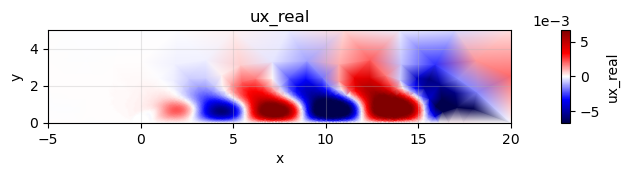

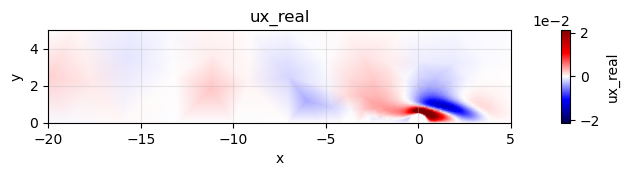

In [29]:
uxFieldDirect.plot(xlim=(-5, 20), ylim=(0, 5))
uxFieldAdjoint.plot(xlim=(-20, 5), ylim=(0, 5))

**6. 🌋 Structural Sensitivity in FELiCS**

In global stability analysis, the **structural sensitivity** — often called the _wavemaker_ — identifies the regions in the flow where small changes in the operator have the strongest impact on the eigenvalue.
This is precisely the region where an instability is _born_.

This concept was introduced in the seminal paper:
Giannetti & Luchini (2007), “Structural sensitivity of the first instability of the cylinder wake”
Journal of Fluid Mechanics, 581: 167–197.
doi: [10.1017/S0022112007005654](https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/structural-sensitivity-of-the-first-instability-of-the-cylinder-wake/020BE9D060A70BD7FE0301965AC81DB3)

Their analysis showed that, at the Hopf bifurcation of the cylinder wake, the wavemaker is a compact bubble located just downstream of the cylinder, at the intersection between:
- regions where the direct mode is energetic (perturbation amplification), and
- regions where the adjoint mode is energetic (flow receptivity).
Understanding this overlap region is essential for model reduction, flow control, and sensitivity-based design.

**📐 (Abbreviated) Mathematical definition**
Given a direct velocity mode $u_d(x)$ and the corresponding adjoint mode $u_a(x)$, the structural sensitivity tensor is

$$
\mathbf{S}(x) = u_d(x) \otimes u_a^*(x)
$$

Its Frobenius norm is a scalar field that gives the maximum possible structural sensitivity in each point:

$$
\lVert \mathbf{S}(x) \rVert_F = \lVert u_d(x) \rVert \, \lVert u_a(x) \rVert
$$

**🛠️ How to evaluate tensor expressions in FELiCS (essentials)**
```evaluateUflTensorExpression``` is a compact but powerful FELiCS routine that **evaluates any tensor-based UFL expression and stores the result in a Field**. It is the recommended way to compute derived quantities (e.g. structural sensitivity, vorticity, energy norms) because it:

- ✔ **Uses the FELiCS tensor framework:**
The expression is interpreted using ```Tensor```, ```iDot```, ```iConj```, and the coordinate-system Jacobian ```J_hat```, ensuring that all operators follow the correct physics, including non-Cartesian coordinate systems and spectral directions. (A pure-ufl version of this function exist with ```evaluateUflExpression```)
- ✔ **Automatically assembles a consistent weak form:**
The method builds the appropriate “mass-like” variational form for the field’s function space, assembles it once, and stores the corresponding LU solver for reuse.
- ✔ **Efficiently evaluates and inserts the result:**
The input expression is assembled into a vector, solved with the precomputed solver, and the field’s coefficient array is updated.
- ✔ **Ideal for post-processing:**
You can turn complex mathematical expressions directly into FEM fields with one line, without manually writing projection operators or variational problems.

**🧠 Structural sensitivity in FELiCS**
FELiCS uses a tensor-aware framework for field representation.
This allows us to compute expressions like structural sensitivity in a coordinate-system consistent way.

The computational steps are:
- 🔍 Extract the direct and adjoint velocity fluctuation fields.
- 🧮 Choose a scalar FE space $V$ to store the sensitivity.
- ✏️ Build the appropriate UFL tensor expression
- ⚙️ Assemble the expression using ```evaluateUflTensorExpression```.
- 🎨 Plot the resulting scalar field.

**🧩 FELiCS implementation**

In [30]:
# --- Extract direct and adjoint velocity fields -----------------------
uFieldDirect  = directMode.get_list_of_sub_fields()[0]   # velocity fluctuation
uFieldAdjoint = adjointMode.get_list_of_sub_fields()[0]

# --- Test space where the scalar sensitivity will live ---------------
V_scalar = FEMSpaces.P2
v        = ufl.TestFunction(V_scalar)

# --- Create empty field to store structural sensitivity --------------
sS       = Field(V_scalar, mesh)
sS.name  = "StructuralSensitivity"

# --- Build the UFL tensor expression ---------------------------------
J_hat  = sS.mesh.coordinate_system.J_hat

v_tens = Tensor(
    v,
    CoordSys=sS.mesh.coordinate_system,
    m=sS.m,
    mayHaveSpectralDimension=sS.hasSpectralDimension,
)

exprSS = (
    i_dot(uFieldDirect.get_tensor(),  i_conj(uFieldDirect.get_tensor()))**0.5 *
    i_dot(uFieldAdjoint.get_tensor(), i_conj(uFieldAdjoint.get_tensor()))**0.5 *
    i_conj(v_tens)
).ufl_tens * J_hat * ufl.dx

# --- Evaluate expression and build the finite-element field -----------
sS.evaluate_ufl_tensor_expression(exprSS)

**🎨 Plotting the result**

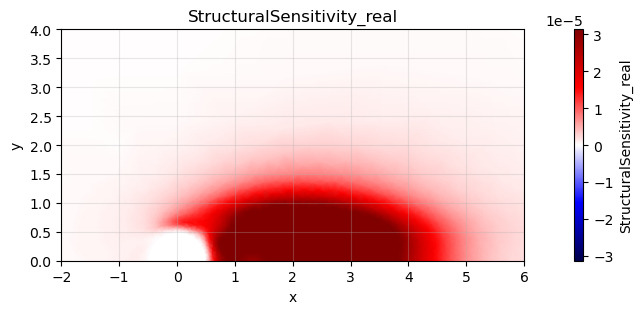

In [31]:
sS.plot(xlim=(-2, 6), ylim=(0, 4))